In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'notebook', 'no-latex'])
from scipy.special import wofz

In [13]:
# unit_conversion_paramters
kms_to_cms = 1e5
mpc_to_cm = 3.086e24
ang_to_cm = 1e-8

# physical_constants
c = 2.99792458e10
kB = 1.380658e-16
mp = 1.6726e-24
me = 9.1094e-28
mn = 1.6749286e-24

# cosmological parameters
omega_m = 0.308
omega_l  = 0.692
omega_r  = 0.0
omega_k = 0.0
omega_b = 0.0482
hubble_param = 0.678
sigma_8 = 0.829
Y  = 0.24
ns = 0.961

# atomic_constants
# for Ly alpha
lambda_r = 1215.6701
f12 = 0.416
damp_gamma = 6.265e8
ialpha = 4.469e-18
np_ = 1
ne = 1
nn = 0

In [14]:
def calculate_profile(z_val,z_arr,vXI_arr_1d,bXI_arr_1d,nXI_arr_1d, lambda_in_cm, damp_gamma, c):
    # note: everything here is in CGS (cm/s)
    velocity_factor_array = (vXI_arr_1d + (c*(z_arr-z_val)/(1+z_val)))/bXI_arr_1d
    alpha_factor_arr = (damp_gamma*lambda_in_cm)/(4*np.pi*bXI_arr_1d)
    z_complex_arr = velocity_factor_array + 1j*alpha_factor_arr
    voigt_calc = wofz(z_complex_arr).real
    tau_val_pixel = np.sum(nXI_arr_1d*voigt_calc/(bXI_arr_1d*(1.0+z_arr)), axis=0)
    return tau_val_pixel

In [15]:
# implement periodic boundary conditions
def calculate_profile_with_BCs(z_val,z_arr,vXI_arr_1d,bXI_arr_1d,nXI_arr_1d, lambda_in_cm, damp_gamma, c):
    # note: everything here is in CGS (cm/s)
    velocity_factor_array = (vXI_arr_1d + (c*(z_arr-z_val)/(1+z_val)))/bXI_arr_1d
    alpha_factor_arr = (damp_gamma*lambda_in_cm)/(4*np.pi*bXI_arr_1d)
    z_complex_arr = velocity_factor_array + 1j*alpha_factor_arr
    voigt_calc = wofz(z_complex_arr).real
    tau_val_pixel = np.sum(nXI_arr_1d*voigt_calc/(bXI_arr_1d*(1.0+z_arr)), axis=0)
    return tau_val_pixel

In [16]:
npixel = 2048
nlos = 1
lambda_in_cm = lambda_r*ang_to_cm
dl_box_cm = 40*mpc_to_cm/npixel/hubble_param

In [19]:
z_arr = z_arr = np.linspace(2.97,3.03,2048) 
v_gas_arr = np.zeros((npixel,nlos))
n_HI_arr = np.zeros((npixel,nlos))
T_gas_arr = np.zeros((npixel,nlos))
tau_HI_arr = np.zeros((npixel,nlos)) # we will compute tau for comparison

b_gas_arr = np.sqrt(2*kB*T_gas_arr/(mp+me)) 

In [8]:
def generate_spectra(z_arr,n_HI_arr_1d,b_gas_arr_1d,v_gas_arr_1d,tau_HI_arr_1d):
    for pixel_idx in range(npixel):
        z_val = z_arr[pixel_idx]
        tau_HI_arr_val = calculate_profile(z_val,z_arr,v_gas_arr_1d,b_gas_arr_1d,n_HI_arr_1d,lambda_in_cm, damp_gamma, c)
        tau_HI_arr_1d[pixel_idx] = tau_HI_arr_val

    tau_HI_arr_1d = tau_HI_arr_1d*c*ialpha*dl_box_cm/np.sqrt(np.pi)
    return tau_HI_arr_1d

In [20]:
v_gas_arr[:,:] = 0
n_HI_arr[:,:] = 1e-20
T_gas_arr[:,:] = 1e2
tau_HI_arr[:,:] = 0

# nHI of 1e-9 typically corresponds to an overdensity of 1
idx = 1024
n_HI_arr[idx, :] = 1e-5
T_gas_arr[idx, :] = 1e4
b_gas_arr = np.sqrt(2*kB*T_gas_arr/(mp+me)) 

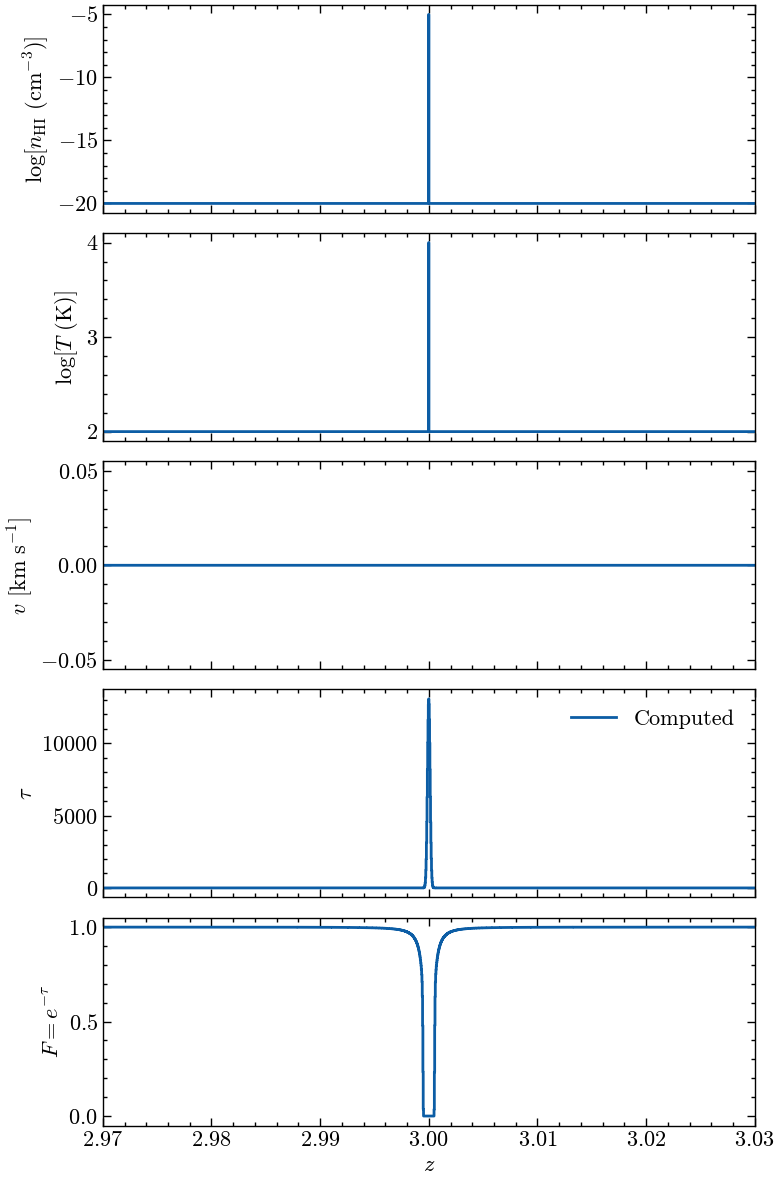

In [21]:
for los_idx in [0]:#range(nlos):
    n_HI_arr_1d = n_HI_arr[:,los_idx]
    b_gas_arr_1d = b_gas_arr[:,los_idx]
    v_gas_arr_1d = v_gas_arr[:,los_idx]
    tau_HI_arr_1d = tau_HI_arr[:, los_idx]

    tau_HI_arr_1d = generate_spectra(z_arr,n_HI_arr_1d,b_gas_arr_1d,v_gas_arr_1d,tau_HI_arr_1d)
    tau_HI_arr[:,los_idx] = tau_HI_arr_1d # update with computed tau

    # now plot
    fig, ax = plt.subplots(nrows=5,sharex=True, figsize=(8,12))

    ax[0].step(z_arr, np.log10(n_HI_arr[:,los_idx]))
    ax[1].step(z_arr, np.log10(T_gas_arr[:, los_idx]))
    ax[2].step(z_arr, v_gas_arr[:, los_idx] / kms_to_cms) 
    ax[3].step(z_arr, tau_HI_arr[:, los_idx], label='Computed')
    ax[4].step(z_arr, np.exp(-tau_HI_arr[:, los_idx]))
    
    ax[3].legend()
    ax[0].set_ylabel(r'$\log [n_\mathrm{HI}$ (cm$^{-3}$)]')
    ax[1].set_ylabel(r'$\log [T$ (K)]')
    ax[2].set_ylabel(r'$v$ [km s$^{-1}$]')
    ax[3].set_ylabel(r'$\tau$')
    ax[4].set_ylabel(r'$F = e^{-\tau}$')
    ax[4].set_xlabel(r'$z$')
    ax[4].set_xlim(z_arr[0],z_arr[-1])

    plt.tight_layout()
    # plt.savefig('figures/mocklines_2.png')
    plt.show()
    plt.close()

    break 